In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343.0,yes,no,unknown,5.0,may,1042.0,1.0,-1.0,0.0,unknown,yes
1,56,admin.,married,secondary,no,45.0,no,no,unknown,5.0,may,1467.0,1.0,-1.0,0.0,unknown,yes
2,41,technician,married,secondary,no,1270.0,yes,no,unknown,5.0,may,1389.0,1.0,-1.0,0.0,unknown,yes
3,54,admin.,married,tertiary,no,184.0,no,no,unknown,5.0,may,673.0,2.0,-1.0,0.0,unknown,yes
4,42,management,single,tertiary,no,0.0,yes,yes,unknown,5.0,may,562.0,2.0,-1.0,0.0,unknown,yes


---
### **EDA**

In [3]:
df.shape

(8912, 17)

In [4]:
df["loan"].value_counts()

loan
no     7703
yes    1179
Name: count, dtype: int64

In [5]:
df["deposit"].value_counts()

deposit
no     4673
yes    4230
Name: count, dtype: int64

In [6]:
df["pdays"].value_counts()

pdays
-1.0      6491
 92.0       86
 91.0       71
 182.0      67
 181.0      63
          ... 
 62.0        1
 701.0       1
 252.0       1
 118.0       1
 317.0       1
Name: count, Length: 439, dtype: int64

In [7]:
df["default"].value_counts()

default
no     8762
yes     146
Name: count, dtype: int64

In [8]:
df["poutcome"].value_counts()

poutcome
unknown    6638
failure     979
success     880
other       415
Name: count, dtype: int64

In [9]:
df.drop(["poutcome", "day", "month"], axis=1, inplace=True)

In [10]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous',
       'deposit'],
      dtype='object')

In [11]:
df["contact"].value_counts()

contact
cellular     6381
unknown      1876
telephone     624
Name: count, dtype: int64

In [12]:
df["contact"] = df["contact"].replace("unknown", "telephone")

In [13]:
df["contact"].value_counts()

contact
cellular     6381
telephone    2500
Name: count, dtype: int64

In [14]:
df["deposit"].value_counts()

deposit
no     4673
yes    4230
Name: count, dtype: int64

In [15]:
df["pdays"].nunique()

439

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8912 entries, 0 to 8911
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        8912 non-null   int64  
 1   job        8905 non-null   object 
 2   marital    8743 non-null   object 
 3   education  8885 non-null   object 
 4   default    8908 non-null   object 
 5   balance    8899 non-null   float64
 6   housing    8899 non-null   object 
 7   loan       8882 non-null   object 
 8   contact    8881 non-null   object 
 9   duration   8905 non-null   float64
 10  campaign   8904 non-null   float64
 11  pdays      8767 non-null   float64
 12  previous   8909 non-null   float64
 13  deposit    8903 non-null   object 
dtypes: float64(5), int64(1), object(8)
memory usage: 974.9+ KB


In [17]:
df.select_dtypes(include=["object"]).columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'deposit'],
      dtype='object')

---
### **Handling Nulls**

In [18]:
df.isnull().sum()[df.isnull().sum() > 0]

job            7
marital      169
education     27
default        4
balance       13
housing       13
loan          30
contact       31
duration       7
campaign       8
pdays        145
previous       3
deposit        9
dtype: int64

In [19]:
df = df.dropna(
    subset=[
        "job",
        "default",
        "balance",
        "housing",
        "duration",
        "campaign",
        "previous",
        "deposit",
        "education",
        "loan",
        "contact"
    ]
)

In [20]:
df.shape

(8845, 14)

In [21]:
df.isnull().sum()[df.isnull().sum() > 0]

marital    121
pdays      117
dtype: int64

In [22]:
df["marital"] = df.groupby(["age", "job"])["marital"].transform(
    lambda x: x.fillna(x.mode()[0])
)

In [23]:
df.isnull().sum()

age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
contact        0
duration       0
campaign       0
pdays        117
previous       0
deposit        0
dtype: int64

In [24]:
df["pdays"] = df["pdays"].fillna(df["pdays"].median())

In [25]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
duration     0
campaign     0
pdays        0
previous     0
deposit      0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8845 entries, 0 to 8911
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        8845 non-null   int64  
 1   job        8845 non-null   object 
 2   marital    8845 non-null   object 
 3   education  8845 non-null   object 
 4   default    8845 non-null   object 
 5   balance    8845 non-null   float64
 6   housing    8845 non-null   object 
 7   loan       8845 non-null   object 
 8   contact    8845 non-null   object 
 9   duration   8845 non-null   float64
 10  campaign   8845 non-null   float64
 11  pdays      8845 non-null   float64
 12  previous   8845 non-null   float64
 13  deposit    8845 non-null   object 
dtypes: float64(5), int64(1), object(8)
memory usage: 1.0+ MB


---
### **Outliers**

In [28]:
df.select_dtypes(include=["int64", "float64"]).describe()

,age,balance,duration,campaign,pdays,previous
count,8845.000000,8845.000000,8845.000000,8845.000000,8845.000000,8845.000000
mean,41.277671,1539.931487,371.228378,2.507631,51.985529,0.840362
std,11.855731,3301.783300,347.968566,2.768685,108.726955,2.311960
min,18.000000,-3058.000000,3.000000,1.000000,-1.000000,0.000000
25%,32.000000,121.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,553.000000,254.000000,2.000000,-1.000000,0.000000
75%,49.000000,1724.000000,491.000000,3.000000,53.000000,1.000000
max,95.000000,81204.000000,3284.000000,63.000000,842.000000,58.000000


In [29]:
df["pdays"].value_counts().head(10)

pdays
-1.0      6569
 92.0       86
 91.0       71
 182.0      67
 181.0      63
 183.0      56
 184.0      44
 94.0       37
 93.0       35
 95.0       32
Name: count, dtype: int64

In [30]:
df["balance"].value_counts().sort_values(ascending=False)

balance
 0.0       615
 1.0        33
 3.0        27
 2.0        26
 5.0        23
          ... 
 4527.0      1
-516.0       1
 2257.0      1
 3168.0      1
 3090.0      1
Name: count, Length: 3424, dtype: int64

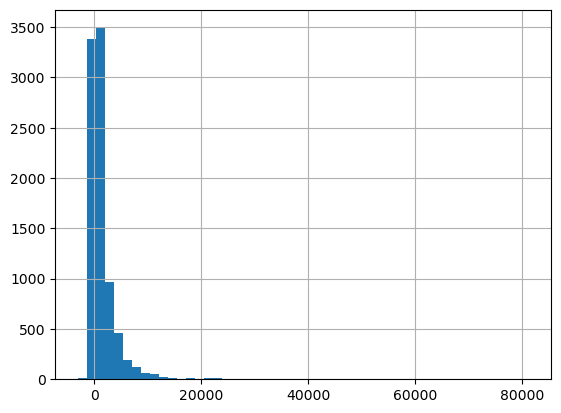

In [31]:
df["balance"].hist(bins=50)
plt.show()

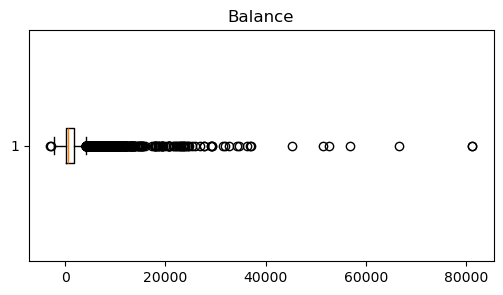

In [32]:
plt.figure(figsize=(6,3))
plt.boxplot(df["balance"], vert=False)
plt.title("Balance")
plt.show()

In [33]:
num = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in num:
    print(f"Column name: {col}")

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"Number of outliers: {len(outliers)}")
    print("-" * 40)

Column name: age
Number of outliers: 128
----------------------------------------
Column name: balance
Number of outliers: 837
----------------------------------------
Column name: duration
Number of outliers: 519
----------------------------------------
Column name: campaign
Number of outliers: 465
----------------------------------------
Column name: pdays
Number of outliers: 1498
----------------------------------------
Column name: previous
Number of outliers: 1003
----------------------------------------


In [34]:
Q1 = df["balance"].quantile(0.25)
Q3 = df["balance"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["balance"] = df["balance"].clip(lower, upper)

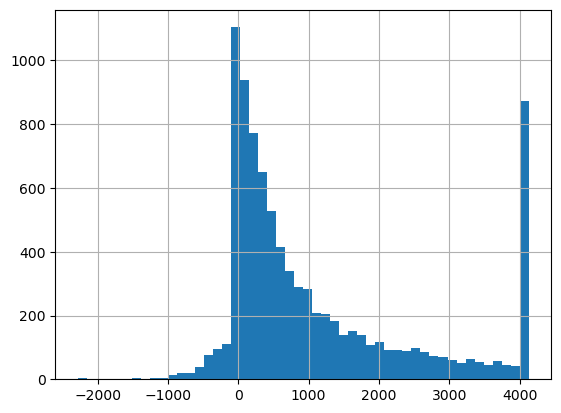

In [35]:
df["balance"].hist(bins=50)
plt.show()

In [36]:
obj = df.select_dtypes(include="object").columns.tolist()

for col in obj:
    print(f"Column name: {col}")
    print(df[col].value_counts())
    print("-" * 40)

Column name: job
job
management       2067
blue-collar      1539
technician       1449
admin.           1052
services          735
retired           602
self-employed     311
unemployed        292
student           278
entrepreneur      248
housemaid         215
unknown            57
Name: count, dtype: int64
----------------------------------------
Column name: marital
marital
married     5053
single      2781
divorced    1011
Name: count, dtype: int64
----------------------------------------
Column name: education
education
secondary    4340
tertiary     2931
primary      1189
unknown       385
Name: count, dtype: int64
----------------------------------------
Column name: default
default
no     8701
yes     144
Name: count, dtype: int64
----------------------------------------
Column name: housing
housing
no     4636
yes    4209
Name: count, dtype: int64
----------------------------------------
Column name: loan
loan
no     7674
yes    1171
Name: count, dtype: int64
----------------

In [37]:
df["job"] = df["job"].replace("unknown", df["job"].mode()[0])

In [38]:
pd.crosstab(df["education"], df["deposit"], normalize="index")

deposit,no,yes
education,,
primary,0.608074,0.391926
secondary,0.556221,0.443779
tertiary,0.461276,0.538724
unknown,0.477922,0.522078


---
### **Encoding**

In [39]:
education_map = {
    "unknown": -1,
    "primary": 0,
    "secondary": 1,
    "tertiary": 2
}

df["education"] = df["education"].map(education_map)

In [40]:
df["education"].value_counts()

education
 1    4340
 2    2931
 0    1189
-1     385
Name: count, dtype: int64

In [41]:
df["job"].value_counts()

job
management       2124
blue-collar      1539
technician       1449
admin.           1052
services          735
retired           602
self-employed     311
unemployed        292
student           278
entrepreneur      248
housemaid         215
Name: count, dtype: int64

In [42]:
df["default"] = df["default"].map({"no": 0, "yes": 1})
df["housing"] = df["housing"].map({"no": 0, "yes": 1})
df["loan"] = df["loan"].map({"no": 0, "yes": 1})
df["deposit"] = df["deposit"].map({"no": 0, "yes": 1})
df["contact"] = df["contact"].map({"telephone": 0, "cellular": 1})

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8845 entries, 0 to 8911
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        8845 non-null   int64  
 1   job        8845 non-null   object 
 2   marital    8845 non-null   object 
 3   education  8845 non-null   int64  
 4   default    8845 non-null   int64  
 5   balance    8845 non-null   float64
 6   housing    8845 non-null   int64  
 7   loan       8845 non-null   int64  
 8   contact    8845 non-null   int64  
 9   duration   8845 non-null   float64
 10  campaign   8845 non-null   float64
 11  pdays      8845 non-null   float64
 12  previous   8845 non-null   float64
 13  deposit    8845 non-null   int64  
dtypes: float64(5), int64(7), object(2)
memory usage: 1.0+ MB


In [44]:
df = pd.get_dummies(
    df,
    columns=["job", "marital"],
    drop_first=True
)

In [45]:
df.shape

(8845, 24)

In [46]:
df.head()

,age,education,default,balance,housing,loan,contact,duration,campaign,pdays,...,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single
0,59,1,0,2343.0,1,0,0,1042.0,1.0,-1.0,...,False,False,False,False,False,False,False,False,True,False
1,56,1,0,45.0,0,0,0,1467.0,1.0,-1.0,...,False,False,False,False,False,False,False,False,True,False
2,41,1,0,1270.0,1,0,0,1389.0,1.0,-1.0,...,False,False,False,False,False,False,True,False,True,False
3,54,2,0,184.0,0,0,0,673.0,2.0,-1.0,...,False,False,False,False,False,False,False,False,True,False
4,42,2,0,0.0,1,1,0,562.0,2.0,-1.0,...,False,True,False,False,False,False,False,False,False,True


---
### **Data Splitting**

In [50]:
from sklearn.model_selection import train_test_split

X = df.drop("deposit", axis=1)
y = df["deposit"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

---
### **Normalization**

In [51]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

num_cols = ["age", "balance", "duration", "campaign", "pdays", "previous"]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [52]:
X_train.head()

,age,education,default,balance,housing,loan,contact,duration,campaign,pdays,...,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single
6081,-0.352941,-1,0,-0.100107,1,0,1,1.398876,1.0,0.000000,...,False,False,False,False,True,False,False,False,False,False
4624,0.705882,2,0,-0.267772,0,0,1,-0.154494,-0.5,2.666667,...,False,True,False,False,False,False,False,False,False,False
1412,-0.176471,2,0,1.637341,0,0,1,0.188202,4.5,0.000000,...,False,False,False,False,False,False,False,False,True,False
5478,-0.705882,1,0,0.226624,1,0,1,-0.480337,-0.5,0.000000,...,False,True,False,False,False,False,False,False,False,True
7706,-0.647059,0,0,-0.195916,0,0,1,0.575843,0.5,0.000000,...,False,False,False,False,False,False,False,True,False,True


---
### **Model**

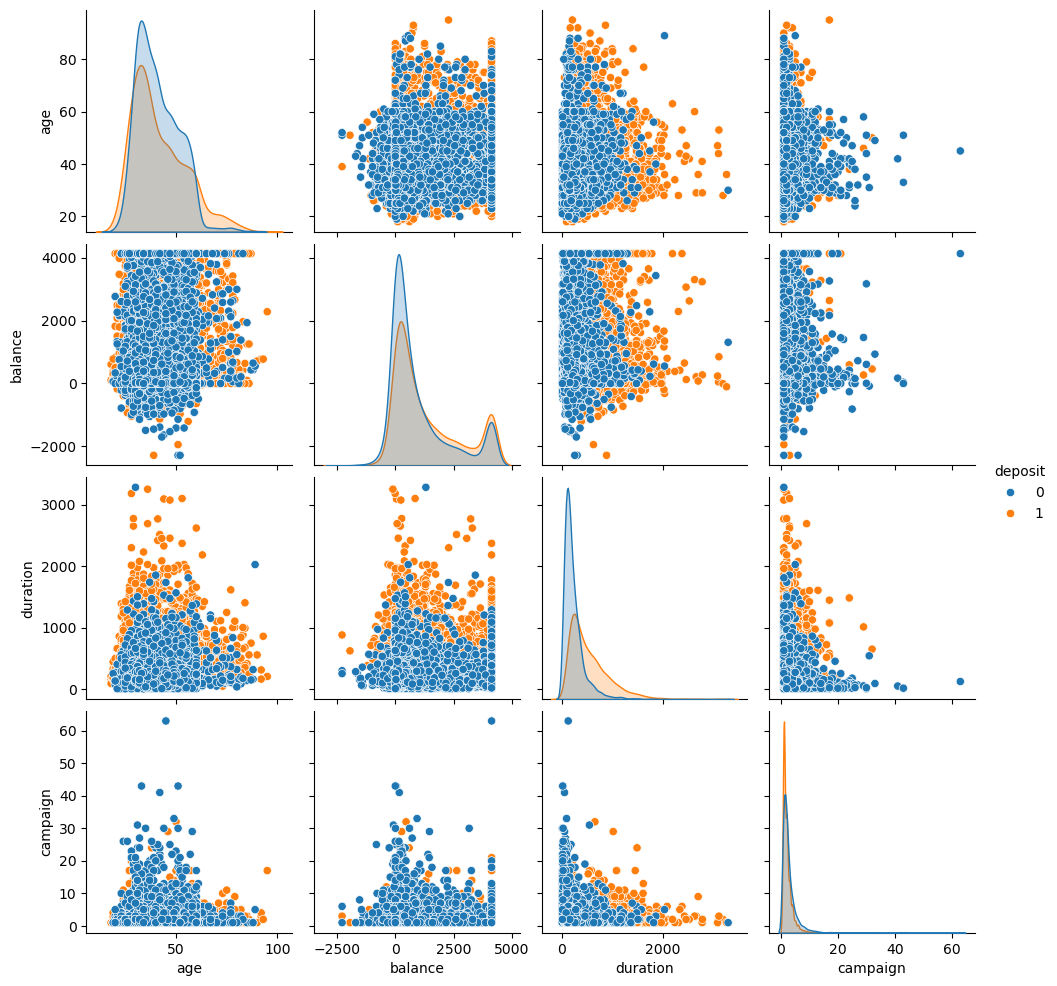

In [54]:
import seaborn as sns
sns.pairplot(
    df,
    vars=["age", "balance", "duration", "campaign"],
    hue="deposit"
)

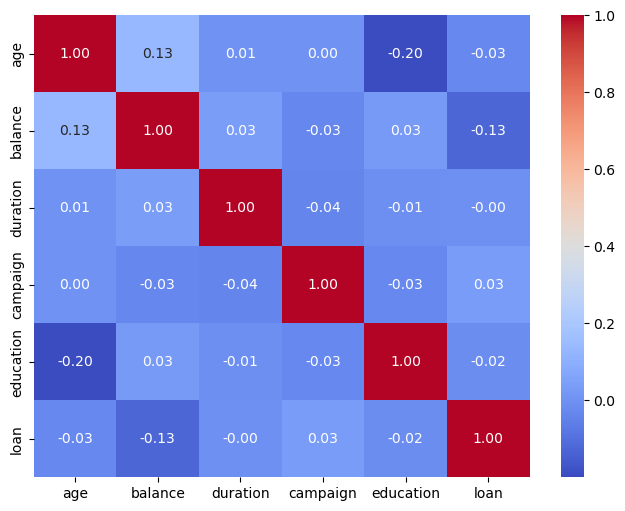

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[["age", "balance", "duration", "campaign", "education", "loan"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

params = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 1, 0.1, 0.01, 0.001],
    "kernel": ["rbf"]
}

grid = GridSearchCV(SVC(), params, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


In [56]:
model = SVC(C=10 ,gamma= 0.01 ,kernel="rbf")
model.fit(X_train, y_train)

SVC(C=10, gamma=0.01)

In [60]:
y_pred = model.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7970604861503674


In [62]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[739 196]
 [163 671]]


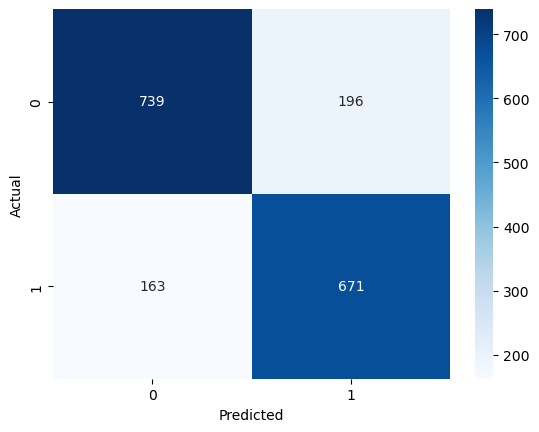

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.79      0.80       935
           1       0.77      0.80      0.79       834

    accuracy                           0.80      1769
   macro avg       0.80      0.80      0.80      1769
weighted avg       0.80      0.80      0.80      1769



In [65]:
model.score(X_train, y_train)

0.8151498021481063

In [66]:
model.score(X_test, y_test)

0.7970604861503674